In [215]:
#1- Import the dataset.
import pandas as pd

df = pd.read_csv("raw-healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [216]:
#2- Google Drive to access dataset files stored in Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [217]:
#3- Google Drive to load and save files
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [218]:
#4- COPY DATASET
# Make a copy before any changes
df_before = df.copy()

# DO NOT drop missing values here
# We will handle them properly later

print("Shape:")
print("Before:", df_before.shape)
print("Current:", df.shape)

Shape:
Before: (5110, 12)
Current: (5110, 12)


In [219]:
#5- Split the dataset.
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (validation + test)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# Second split: split temp into 50% validation and 50% test
# (because 15% is half of 30%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Print shapes to verify
print("Dataset shape:", df.shape)
print("Training set shape (70%):", train_df.shape)
print("Validation set shape (15%):", val_df.shape)
print("Testing set shape (15%):", test_df.shape)

# view data
print(train_df)
print(val_df)
print(test_df)

Dataset shape: (5110, 12)
Training set shape (70%): (3577, 12)
Validation set shape (15%): (766, 12)
Testing set shape (15%): (767, 12)
         id  gender    age  hypertension  heart_disease ever_married  \
3897  24257    Male   4.00             0              0           No   
576   56179    Male  29.00             0              0           No   
4013  36388    Male  44.00             1              0          Yes   
4536  59405  Female  68.00             1              0          Yes   
1180  46643  Female  62.00             0              0          Yes   
...     ...     ...    ...           ...            ...          ...   
4426  13846    Male  43.00             0              0          Yes   
466    1307  Female  61.00             1              0          Yes   
3092  31481  Female   1.16             0              0           No   
3772  61827    Male  80.00             0              0          Yes   
860   28933  Female  46.00             0              0          Yes   


In [220]:
#6- Save test dataset
test_df.to_csv("healthcare-dataset-stroke-test.csv", index=False)

# Save validation dataset
val_df.to_csv("healthcare-dataset-stroke-validation.csv", index=False)

print("Test dataset saved as 'healthcare-dataset-stroke-test.csv'")
print("Validation dataset saved as 'healthcare-dataset-stroke-validation.csv'")

Test dataset saved as 'healthcare-dataset-stroke-test.csv'
Validation dataset saved as 'healthcare-dataset-stroke-validation.csv'


In [221]:
#7- Analyze the raw dataset.

df.head()        # First 5 rows
df.info()        # Column names and data types
df.describe()    # Statistics
df.isnull().sum()  # Count missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [222]:
#8- Statistic resume
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [223]:
#9- Find missing values
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [224]:
#10- Verify the BMI missing values
df[df.bmi.isnull()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


In [225]:
#11- Analyzing the BMI
df.bmi.describe()

,bmi
count,4909.000000
mean,28.893237
std,7.854067
min,10.300000
25%,23.500000
50%,28.100000
75%,33.100000
max,97.600000


<Axes: ylabel='Frequency'>

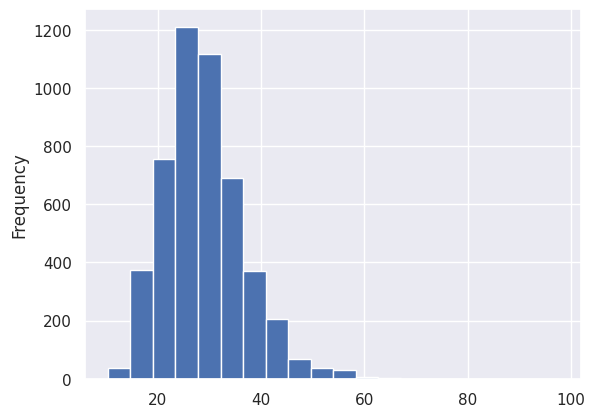

In [226]:
#12- Histogram showing the distribution of BMI values in the dataset
df.bmi.plot.hist(bins=20)

In [227]:
#13- Median of BMI based in age and gender.
df.groupby(["age","gender"])[["bmi"]].median()

bmi
age   gender       
0.08  Female  14.10
      Male    16.90
0.16  Male    13.90
0.24  Male    18.50
0.32  Female  16.20
...             ...
80.00 Male    29.45
81.00 Female  27.75
      Male    27.35
82.00 Female  27.00
      Male    27.50

[206 rows x 1 columns]

In [228]:
#14- Missing BMI by age and gender.
df[df["bmi"].isna()].groupby(["age","gender"]).size()

age    gender
0.48   Male      1
1.08   Male      1
1.32   Female    1
       Male      1
1.80   Male      1
                ..
78.00  Male      6
79.00  Female    4
       Male      4
80.00  Female    3
82.00  Female    1
Length: 113, dtype: int64

In [229]:
#15- As seen on number 4 and 9 same ages but one smoke another one don't, same bmi.
df['bmi_check_1'] = df.groupby(["age","gender"])[["bmi"]].transform('median')
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_check_1
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,29.45
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,29.30
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,29.45
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,29.70
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,28.20
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,27.35
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,27.55
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,30.80
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1,29.40
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1,27.80


In [230]:
#16- Check the missed BMI filled with the median value based on age and gender.
df['bmi_check_2'] = df.bmi.fillna(df.groupby(["age","gender"])["bmi"].transform('median'))
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_check_1,bmi_check_2
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,29.45,36.6
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,29.30,29.3
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,29.45,32.5
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,29.70,34.4
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,28.20,24.0
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,27.35,29.0
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,27.55,27.4
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,30.80,22.8
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1,29.40,29.4
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1,27.80,24.2


In [231]:
#17- How many unique values are in each row.
df.nunique()

,0
id,5110
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418


In [232]:
#18- Checked if this is good and than move on, next step is delete previews colunms and keep going.
#Also check if the ever_married, Work_type and residence_type are needed?
df = df.drop(columns=['bmi_check_1', 'bmi_check_2'])
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [233]:
#19- Define BMI based on Gender, Smoking status, heart disease, ever married and work type, this
#Used this because this groups does not have too many specific values.
df['bmi'] = df.groupby(['gender', 'smoking_status', 'heart_disease', 'ever_married', 'work_type'])['bmi'].transform(lambda x: x.fillna(x.median()))

In [234]:
#20- Handle outliers using log1p, then normalize Glucose level between 0 and 1

import numpy as np

# Step 1: Apply log1p transformation to reduce outliers
df['avg_glucose_level_log'] = np.log1p(df['avg_glucose_level'])

# Step 2: Normalize the transformed values (0–1 scaling)
df['avg_glucose_level_norm'] = (
    df['avg_glucose_level_log'] - df['avg_glucose_level_log'].min()
) / (
    df['avg_glucose_level_log'].max() - df['avg_glucose_level_log'].min()
)

df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_log,avg_glucose_level_norm
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,5.436731,0.891344
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.7,never smoked,1,5.314240,0.813868
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,4.672081,0.407703
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,5.148831,0.709247
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,5.165471,0.719772
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,5.232231,0.761998
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,4.263947,0.149558
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,4.557974,0.335530
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,29.0,Unknown,1,4.345752,0.201299
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1,4.087152,0.037735


In [235]:
#21- Normalization of bmi
df['bmi_norm'] = (
    df['bmi'] - df['bmi'].min()
) / (
    df['bmi'].max() - df['bmi'].min()
)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_log,avg_glucose_level_norm,bmi_norm
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,5.436731,0.891344,0.301260
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.7,never smoked,1,5.314240,0.813868,0.210767
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,4.672081,0.407703,0.254296
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,5.148831,0.709247,0.276060
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,5.165471,0.719772,0.156930
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,5.232231,0.761998,0.214204
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,4.263947,0.149558,0.195876
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,4.557974,0.335530,0.143184
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,29.0,Unknown,1,4.345752,0.201299,0.214204
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1,4.087152,0.037735,0.159221


In [236]:
#22- Define age by groups

# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
)

# Convert intervals to numeric codes (VERY IMPORTANT)
df['age_group'] = df['age_group'].cat.codes

df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_log,avg_glucose_level_norm,bmi_norm,age_group
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,5.436731,0.891344,0.301260,6
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.7,never smoked,1,5.314240,0.813868,0.210767,6
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,4.672081,0.407703,0.254296,7
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,5.148831,0.709247,0.276060,4
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,5.165471,0.719772,0.156930,7
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,5.232231,0.761998,0.214204,8
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,4.263947,0.149558,0.195876,7
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,4.557974,0.335530,0.143184,6
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,29.0,Unknown,1,4.345752,0.201299,0.214204,5
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1,4.087152,0.037735,0.159221,7


In [237]:
#23- Hot encoding we decided to use this column because any other one will have more than 2 values.
df = pd.get_dummies(df, columns=['hypertension'])
df.head(10)

,id,gender,age,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_log,avg_glucose_level_norm,bmi_norm,age_group,hypertension_0,hypertension_1
0,9046,Male,67.0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,5.436731,0.891344,0.301260,6,True,False
1,51676,Female,61.0,0,Yes,Self-employed,Rural,202.21,28.7,never smoked,1,5.314240,0.813868,0.210767,6,True,False
2,31112,Male,80.0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,4.672081,0.407703,0.254296,7,True,False
3,60182,Female,49.0,0,Yes,Private,Urban,171.23,34.4,smokes,1,5.148831,0.709247,0.276060,4,True,False
4,1665,Female,79.0,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,5.165471,0.719772,0.156930,7,False,True
5,56669,Male,81.0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,5.232231,0.761998,0.214204,8,True,False
6,53882,Male,74.0,1,Yes,Private,Rural,70.09,27.4,never smoked,1,4.263947,0.149558,0.195876,7,False,True
7,10434,Female,69.0,0,No,Private,Urban,94.39,22.8,never smoked,1,4.557974,0.335530,0.143184,6,True,False
8,27419,Female,59.0,0,Yes,Private,Rural,76.15,29.0,Unknown,1,4.345752,0.201299,0.214204,5,True,False
9,60491,Female,78.0,0,Yes,Private,Urban,58.57,24.2,Unknown,1,4.087152,0.037735,0.159221,7,True,False


In [238]:
#24- Preprocess
import pandas as pd

# 1. PRE-CLEANING: Standardize all text columns first
# This removes extra spaces and makes everything lowercase so the map works perfectly
text_cols = ['gender', 'smoking_status', 'ever_married', 'Residence_type', 'work_type']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# 2. DEFINE MAPS (using lowercase keys to match our pre-cleaning)
smoking_map = {'never smoked': 0, 'formerly smoked': 1, 'smokes': 2, 'unknown': 3}
gender_map = {'male': 0, 'female': 1, 'other': 2}
married_map = {'yes': 1, 'no': 0}
residence_map = {'urban': 1, 'rural': 0}

# 3. APPLY MAPS
df['smoking_status'] = df['smoking_status'].map(smoking_map)
df['gender'] = df['gender'].map(gender_map)
df['ever_married'] = df['ever_married'].map(married_map)
df['Residence_type'] = df['Residence_type'].map(residence_map)

# 4. HANDLE OTHERS
df['work_type'] = pd.factorize(df['work_type'])[0]

# 5. CONVERT BOOLEANS (Hypertension)
df['hypertension_0'] = df['hypertension_0'].astype(int)
df['hypertension_1'] = df['hypertension_1'].astype(int)

# Check the result
print(df.head(10))

      id  gender   age  heart_disease  ever_married  work_type  \
0   9046       0  67.0              1             1          0   
1  51676       1  61.0              0             1          1   
2  31112       0  80.0              1             1          0   
3  60182       1  49.0              0             1          0   
4   1665       1  79.0              0             1          1   
5  56669       0  81.0              0             1          0   
6  53882       0  74.0              1             1          0   
7  10434       1  69.0              0             0          0   
8  27419       1  59.0              0             1          0   
9  60491       1  78.0              0             1          0   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  \
0               1             228.69  36.6               1       1   
1               0             202.21  28.7               0       1   
2               0             105.92  32.5               0     

In [239]:
#25- Checking all the columns to see which one to drop.

pd.set_option('display.max_columns', None)
df.head(10)

,id,gender,age,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_log,avg_glucose_level_norm,bmi_norm,age_group,hypertension_0,hypertension_1
0,9046,0,67.0,1,1,0,1,228.69,36.6,1,1,5.436731,0.891344,0.301260,6,1,0
1,51676,1,61.0,0,1,1,0,202.21,28.7,0,1,5.314240,0.813868,0.210767,6,1,0
2,31112,0,80.0,1,1,0,0,105.92,32.5,0,1,4.672081,0.407703,0.254296,7,1,0
3,60182,1,49.0,0,1,0,1,171.23,34.4,2,1,5.148831,0.709247,0.276060,4,1,0
4,1665,1,79.0,0,1,1,0,174.12,24.0,0,1,5.165471,0.719772,0.156930,7,0,1
5,56669,0,81.0,0,1,0,1,186.21,29.0,1,1,5.232231,0.761998,0.214204,8,1,0
6,53882,0,74.0,1,1,0,0,70.09,27.4,0,1,4.263947,0.149558,0.195876,7,0,1
7,10434,1,69.0,0,0,0,1,94.39,22.8,0,1,4.557974,0.335530,0.143184,6,1,0
8,27419,1,59.0,0,1,0,0,76.15,29.0,3,1,4.345752,0.201299,0.214204,5,1,0
9,60491,1,78.0,0,1,0,1,58.57,24.2,3,1,4.087152,0.037735,0.159221,7,1,0


In [240]:
#26- Remove the columns that are not needed and will not help in our dataset.
df = df.drop(columns=['id' , 'hypertension_1', 'avg_glucose_level',
                    'bmi', 'age'])
df.head(10)

,gender,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,avg_glucose_level_log,avg_glucose_level_norm,bmi_norm,age_group,hypertension_0
0,0,1,1,0,1,1,1,5.436731,0.891344,0.301260,6,1
1,1,0,1,1,0,0,1,5.314240,0.813868,0.210767,6,1
2,0,1,1,0,0,0,1,4.672081,0.407703,0.254296,7,1
3,1,0,1,0,1,2,1,5.148831,0.709247,0.276060,4,1
4,1,0,1,1,0,0,1,5.165471,0.719772,0.156930,7,0
5,0,0,1,0,1,1,1,5.232231,0.761998,0.214204,8,1
6,0,1,1,0,0,0,1,4.263947,0.149558,0.195876,7,0
7,1,0,0,0,1,0,1,4.557974,0.335530,0.143184,6,1
8,1,0,1,0,0,3,1,4.345752,0.201299,0.214204,5,1
9,1,0,1,0,1,3,1,4.087152,0.037735,0.159221,7,1


In [241]:
#27- Check and fill missing values.
# Check missing values before fixing
print("Missing values BEFORE fixing:\n", df.isnull().sum())

# Fill any remaining NaNs with median (safe for numeric data)
df = df.fillna(df.median(numeric_only=True))

# If any non-numeric columns still have NaN, fill with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Check again
print("\nMissing values AFTER fixing:\n", df.isnull().sum())

Missing values BEFORE fixing:
 gender                    0
heart_disease             0
ever_married              0
work_type                 0
Residence_type            0
smoking_status            0
stroke                    0
avg_glucose_level_log     0
avg_glucose_level_norm    0
bmi_norm                  1
age_group                 0
hypertension_0            0
dtype: int64

Missing values AFTER fixing:
 gender                    0
heart_disease             0
ever_married              0
work_type                 0
Residence_type            0
smoking_status            0
stroke                    0
avg_glucose_level_log     0
avg_glucose_level_norm    0
bmi_norm                  0
age_group                 0
hypertension_0            0
dtype: int64


In [242]:
#28- Final check of cleaned dataset
print("Final Clean Dataset Shape:", df.shape)
print("\nMissing Values per Column:\n", df.isnull().sum())
print("\nFirst 5 rows of Final Clean Dataset:\n")
print(df.head())

Final Clean Dataset Shape: (5110, 12)

Missing Values per Column:
 gender                    0
heart_disease             0
ever_married              0
work_type                 0
Residence_type            0
smoking_status            0
stroke                    0
avg_glucose_level_log     0
avg_glucose_level_norm    0
bmi_norm                  0
age_group                 0
hypertension_0            0
dtype: int64

First 5 rows of Final Clean Dataset:

   gender  heart_disease  ever_married  work_type  Residence_type  \
0       0              1             1          0               1   
1       1              0             1          1               0   
2       0              1             1          0               0   
3       1              0             1          0               1   
4       1              0             1          1               0   

   smoking_status  stroke  avg_glucose_level_log  avg_glucose_level_norm  \
0               1       1               5.436731      

In [243]:
#29- Save the final cleaned dataset to a CSV file
df.to_csv("healthcare-dataset-stroke-cleaned.csv", index=False)
print("Cleaned dataset saved as 'healthcare-dataset-stroke-cleaned.csv'")

Cleaned dataset saved as 'healthcare-dataset-stroke-cleaned.csv'


In [244]:
#30- TRAIN / VAL / TEST SPLIT

from sklearn.model_selection import train_test_split

# Define target variable (stroke is the label in this dataset)
target = 'stroke'

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Print shapes
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (3577, 11)
Validation set: (766, 11)
Test set: (767, 11)


In [245]:
#31- SAVE TEST SET

import pandas as pd

test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv("test_dataset_final.csv", index=False)

print("Test dataset saved and will remain untouched.")

Test dataset saved and will remain untouched.


In [246]:
#32- IMPORT MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [247]:
#33- TRAIN MODELS

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, class_weight='balanced')
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.
KNN trained successfully.
SVC trained successfully.


In [248]:
#34- EVALUATION FUNCTION "How well a function perform based on accurace, precision, recall, F1 and ROC-AUC"

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    # For ROC-AUC (need probabilities)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X)[:, 1]
        roc = roc_auc_score(y, y_proba)
    else:
        roc = None

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC-AUC": roc
    }

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.736292   0.126697  0.756757  0.217054  0.837652
Decision Tree        0.912533   0.031250  0.027027  0.028986  0.492252
Random Forest        0.951697   0.000000  0.000000  0.000000  0.794721
Gradient Boosting    0.947781   0.000000  0.000000  0.000000  0.828847
KNN                  0.950392   0.333333  0.027027  0.050000  0.625310
SVC                  0.678851   0.117216  0.864865  0.206452  0.815037


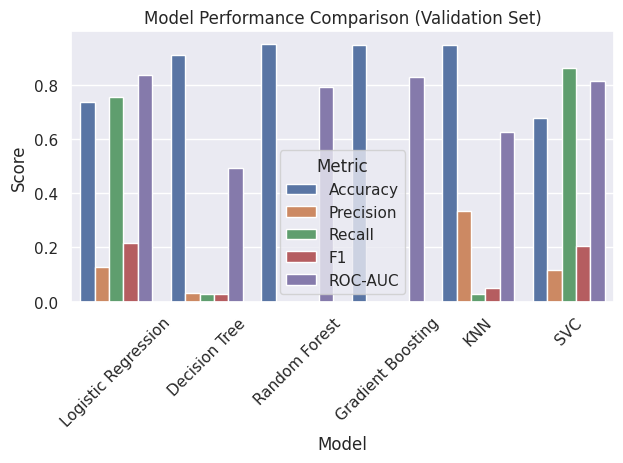

In [249]:
#35- VALIDATE MODELS

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_val, y_val)

# Show results
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

#Bar Chart for a better visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Reset index so "Model" becomes a column
results_df = results_df.reset_index().rename(columns={"index": "Model"})

# Convert to long format (best for seaborn)
long_df = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# Plot grouped bar chart
plt.figure()
sns.barplot(data=long_df, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison (Validation Set)")
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

In [250]:
#36- SELECT BEST MODELS

# Sort by F1-score
top_models = results_df.sort_values(by="F1", ascending=False).head(3)
print("Top 3 Models:")
print(top_models)

Top 3 Models:
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.736292   0.126697  0.756757  0.217054  0.837652
5                  SVC  0.678851   0.117216  0.864865  0.206452  0.815037
4                  KNN  0.950392   0.333333  0.027027  0.050000  0.625310


In [251]:
#37- VOTING ENSEMBLE "Combines predictions from multiple models and makes a final decision based on their votes."

# Get top 3 model names
top_names = top_models["Model"].tolist()

# Create voting classifier
voting_model = VotingClassifier(
    estimators=[(name, models[name]) for name in top_names],
    voting='soft'
)

# Train
voting_model.fit(X_train, y_train)

# Evaluate
voting_results = evaluate_model(voting_model, X_val, y_val)

print("Voting Ensemble Results:")
print(voting_results)
print("Top 3 Models")
print(top_names)

Voting Ensemble Results:
{'Accuracy': 0.9490861618798956, 'Precision': 0.25, 'Recall': 0.02702702702702703, 'F1': 0.04878048780487805, 'ROC-AUC': np.float64(0.8220813405998592)}
Top 3 Models
['Logistic Regression', 'SVC', 'KNN']


In [252]:
#38- AVERAGE PREDICTIONS

import numpy as np

probas = []

for name in top_names:
    probas.append(models[name].predict_proba(X_val)[:, 1])

avg_proba = np.mean(probas, axis=0)
avg_pred = (avg_proba > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score

print("Average Ensemble Accuracy:", accuracy_score(y_val, avg_pred))
print("Average Ensemble F1:", f1_score(y_val, avg_pred))

Average Ensemble Accuracy: 0.9490861618798956
Average Ensemble F1: 0.04878048780487805


In [253]:
#39- BAYESIAN ENSEMBLE (WEIGHTED)"Give more importance to the better models."

# Use F1-score as weights (Bayesian-like approach)
weights = top_models["F1"].values

weighted_probas = []

for i, name in enumerate(top_names):
    prob = models[name].predict_proba(X_val)[:, 1]
    weighted_probas.append(prob * weights[i])

bayesian_proba = np.sum(weighted_probas, axis=0) / np.sum(weights)
bayesian_pred = (bayesian_proba > 0.5).astype(int)

print("Bayesian Ensemble Accuracy:", accuracy_score(y_val, bayesian_pred))
print("Bayesian Ensemble F1:", f1_score(y_val, bayesian_pred))

Bayesian Ensemble Accuracy: 0.9386422976501305
Bayesian Ensemble F1: 0.2033898305084746


In [254]:
#40- FINAL TEST EVALUATION

# --- Voting Model Evaluation ---
print("Final Test Evaluation (Voting Model):")
print(evaluate_model(voting_model, X_test, y_test))


# --- Bayesian Ensemble Evaluation (RECOMPUTED ON TEST SET) ---
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Recompute weighted probabilities using TEST data
weighted_probas_test = []

for i, name in enumerate(top_names):
    prob = models[name].predict_proba(X_test)[:, 1]
    weighted_probas_test.append(prob * weights[i])

# Combine probabilities
bayesian_proba_test = np.sum(weighted_probas_test, axis=0) / np.sum(weights)

# Convert probabilities to class predictions
bayesian_pred_test = (bayesian_proba_test > 0.5).astype(int)

# Evaluate
print("\nFinal Test Evaluation (Bayesian Model):")
print("Accuracy:", accuracy_score(y_test, bayesian_pred_test))
print("F1:", f1_score(y_test, bayesian_pred_test))

Final Test Evaluation (Voting Model):
{'Accuracy': 0.9478487614080835, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC-AUC': np.float64(0.8219984116670277)}

Final Test Evaluation (Bayesian Model):
Accuracy: 0.9335071707953064
F1: 0.10526315789473684


In [255]:
#41- COMPARISON TABLE (VALIDATION + TEST)

import pandas as pd

comparison_results = []

# Loop through all models
for name, model in models.items():

    # Validation metrics
    val_metrics = evaluate_model(model, X_val, y_val)
    val_metrics["Model"] = name
    val_metrics["Dataset"] = "Validation"
    comparison_results.append(val_metrics)

    # Test metrics
    test_metrics = evaluate_model(model, X_test, y_test)
    test_metrics["Model"] = name
    test_metrics["Dataset"] = "Test"
    comparison_results.append(test_metrics)

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Reorder columns
comparison_df = comparison_df[
    ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

# Show table
print(comparison_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  Model     Dataset  Accuracy  Precision    Recall        F1  \
0   Logistic Regression  Validation  0.736292   0.126697  0.756757  0.217054   
1   Logistic Regression        Test  0.705346   0.117886  0.763158  0.204225   
2         Decision Tree  Validation  0.912533   0.031250  0.027027  0.028986   
3         Decision Tree        Test  0.906128   0.113636  0.131579  0.121951   
4         Random Forest  Validation  0.951697   0.000000  0.000000  0.000000   
5         Random Forest        Test  0.949153   0.000000  0.000000  0.000000   
6     Gradient Boosting  Validation  0.947781   0.000000  0.000000  0.000000   
7     Gradient Boosting        Test  0.949153   0.333333  0.026316  0.048780   
8                   KNN  Validation  0.950392   0.333333  0.027027  0.050000   
9                   KNN        Test  0.949153   0.000000  0.000000  0.000000   
10                  SVC  Validation  0.678851   0.117216  0.864865  0.206452   
11                  SVC        Test  0.6

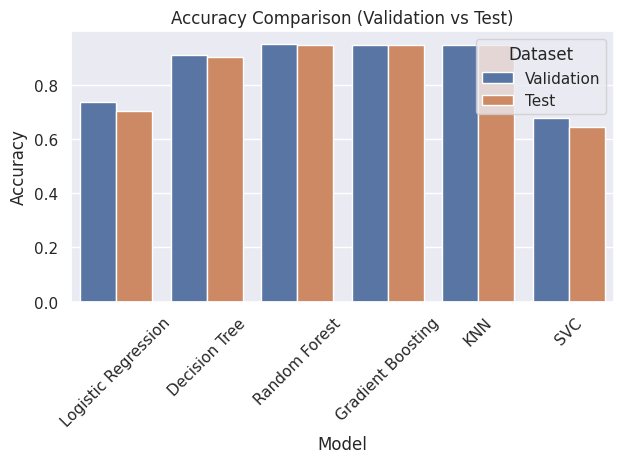

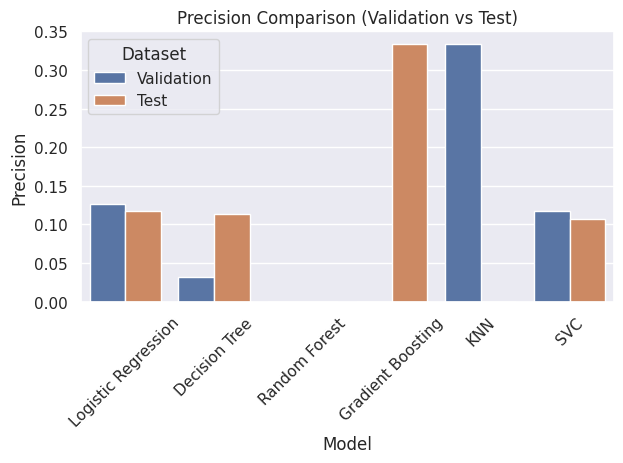

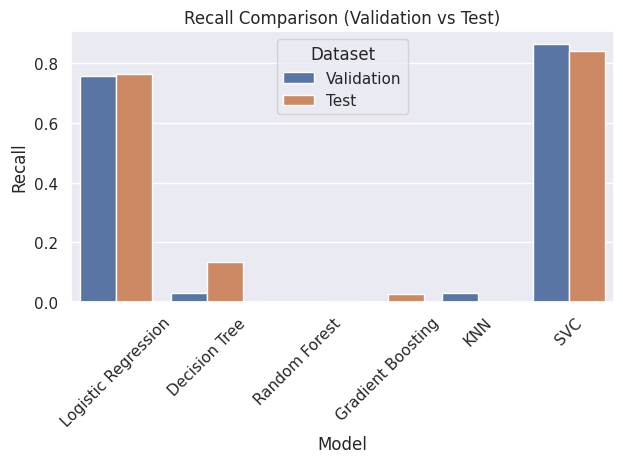

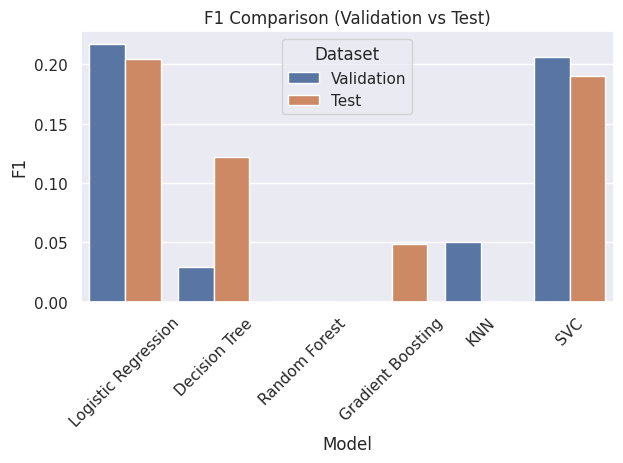

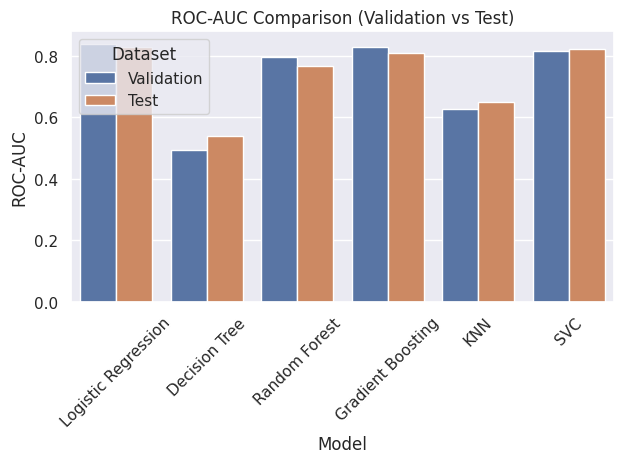

In [256]:
#Bar Char for a better visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
sns.set_theme()

# Metrics you want to plot
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

# Create one chart per metric
for metric in metrics:
    plt.figure()
    sns.barplot(
        data=comparison_df,
        x="Model",
        y=metric,
        hue="Dataset"
    )

    plt.title(f"{metric} Comparison (Validation vs Test)")
    plt.xticks(rotation=45)
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.legend(title="Dataset")

    plt.tight_layout()
    plt.show()

In [257]:
#42- Save the table
comparison_df.to_csv("model_comparison_table.csv", index=False)
print("Table saved!")

Table saved!


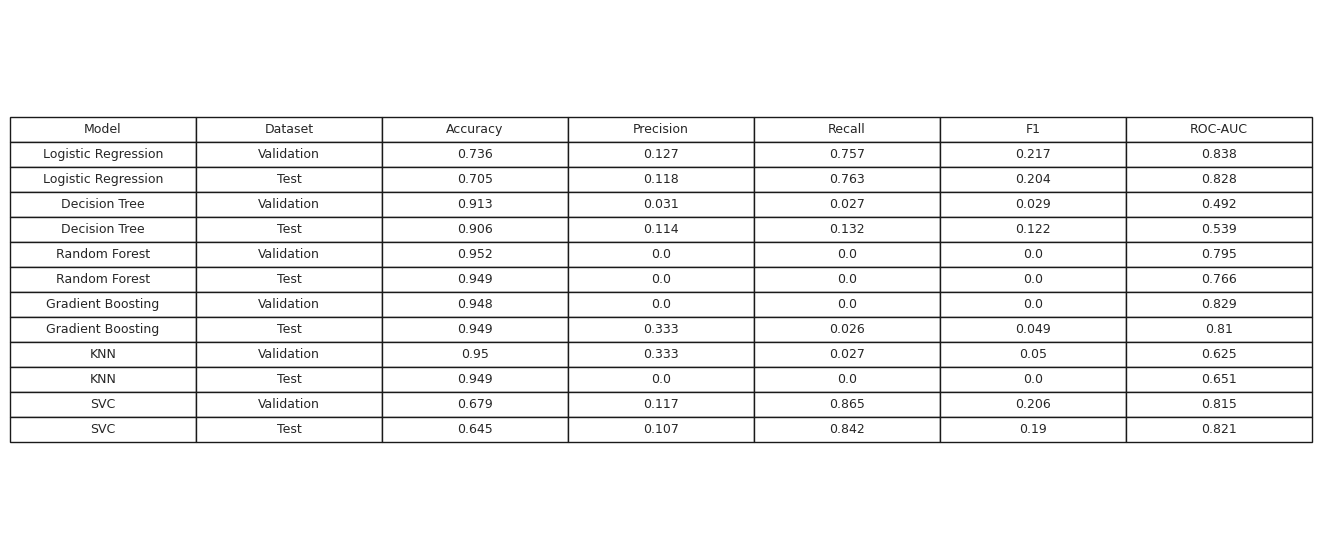

In [258]:
#43- Save the table to .pdf (Round numbers to fit.)
import matplotlib.pyplot as plt

# Round values to 3 decimals (VERY IMPORTANT)
comparison_df_rounded = comparison_df.round(3)

fig, ax = plt.subplots(figsize=(14, 7))  # slightly bigger figure
ax.axis('off')

table = ax.table(
    cellText=comparison_df_rounded.values,
    colLabels=comparison_df_rounded.columns,
    loc='center',
    cellLoc='center'
)

# Improve readability
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)  # widen columns

plt.savefig("model_comparison_table.pdf", bbox_inches='tight')